# Initializations

General imports and seed initializations.

In [11]:
import torch, torchaudio, glob, os, random
import scipy.signal
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import IPython
def seed_everything(seed):      
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True
seed_everything(42)

# Tokenizador de Tarea1_1
class DigitSumTokenizer():    
    def __init__(self):
        self.word2index = {
            'de': 0, 'días': 1, 'el': 2, 'en': 3, 'este': 4,
            'favor': 5, 'gracias': 6, 'jueves': 7, 'lunes': 8, 'martes': 9,
            'mañana': 10, 'miércoles': 11, 'par': 12, 'pasado': 13, 'por': 14,
            'próximo': 15, 'que': 16, 'siguiente': 17, 'tres': 18, 'un': 19,
            'viene': 20, 'viernes': 21, '<pad>': 22, '<sos>': 23, '<eos>': 24,    
        }       
        self.index2word = {v:k for k,v in self.word2index.items()}
    
    def encode(self, x, seq_len=-1):
        x = '<sos> ' + x + ' <eos>'
        x = [self.word2index[w] for w in x.split()]
        if seq_len > len(x):
            x = x + [self.word2index['<pad>']] * (seq_len - len(x))
        return torch.tensor(x)

    def decode(self, x):
        if isinstance(x, torch.Tensor):
            x = x.tolist()
        x = ' '.join([self.index2word[i] for i in x])
        x = x.replace('<sos>', '').replace('<eos>', '').replace('<pad>', '')
        return x.strip()

tokenizer = DigitSumTokenizer()

# Transformer Encoder+Decoder

The transformer encoder is a stack of self-attention and feed-forward layers.
The transformer decoder is a stack of self-attention, cross-attention and feed-forward layers.

In [12]:
class FeedForward(torch.nn.Module):
    def __init__(self, d_model=512, d_ff=1024, dropout=0.1, **kwargs):
        super().__init__()
        self.ff = torch.nn.Sequential(
            torch.nn.LayerNorm(d_model),
            torch.nn.Linear(d_model, d_ff),
            torch.nn.ReLU(),
            torch.nn.Dropout(dropout),
            torch.nn.Linear(d_ff, d_model),
        )
        
    def forward(self, x):
        return self.ff(x)

class SelfAttention(torch.nn.Module):
    def __init__(self, d_model, n_heads=8, d_head=64, dropout=0.1, **kwargs):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_head = d_head
        self.scale = torch.sqrt(torch.tensor(d_head, dtype=torch.float32))
        self.norm = torch.nn.LayerNorm(d_model)
        self.q_linear = torch.nn.Linear(d_model, d_head*n_heads)
        self.v_linear = torch.nn.Linear(d_model, d_head*n_heads)
        self.k_linear = torch.nn.Linear(d_model, d_head*n_heads)
        self.dropout = torch.nn.Dropout(dropout)
        self.out = torch.nn.Linear(d_head*n_heads, d_model)

    def forward(self, x):
        x = self.norm(x)
        b = x.shape[0]
        q = self.q_linear(x).view(b, -1, self.n_heads, self.d_head)
        k = self.k_linear(x).view(b, -1, self.n_heads, self.d_head)
        v = self.v_linear(x).view(b, -1, self.n_heads, self.d_head) 

        scores = torch.einsum('bihd,bjhd->bhij', q, k) / self.scale
     
        att = scores.softmax(dim=-1)
        att = self.dropout(att)

        out = torch.einsum('bhij,bjhd->bihd', att, v).reshape(b, -1, self.n_heads*self.d_head)
        out = self.dropout(out)
        out = self.out(out)
        return out

class Encoder(torch.nn.Module):
    def __init__(self, nb_layers=6, **kwargs):
        super().__init__()        
        self.seq_len = kwargs['seq_len']
        self.pos = torch.nn.Parameter(torch.randn(1, self.seq_len, kwargs['d_model']))
        self.att = torch.nn.ModuleList([SelfAttention(**kwargs) for _ in range(nb_layers)])
        self.ff = torch.nn.ModuleList([FeedForward(**kwargs) for _ in range(nb_layers)])
        
    def forward(self, x):
        b, t, d = x.shape
        x = x + self.pos[:, :t, :]
        for att, ff in zip(self.att, self.ff):
            x = x + att(x)
            x = x + ff(x)            
        return x


class CausalSelfAttention(torch.nn.Module):
    def __init__(self, d_model, n_heads=8, d_head=64, dropout=0.1, **kwargs):
        super().__init__()
        self.seq_len = kwargs['seq_len']
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_head = d_head
        self.scale = torch.sqrt(torch.tensor(d_head, dtype=torch.float32))
        self.norm = torch.nn.LayerNorm(d_model)
        self.q_linear = torch.nn.Linear(d_model, d_head*n_heads)
        self.v_linear = torch.nn.Linear(d_model, d_head*n_heads)
        self.k_linear = torch.nn.Linear(d_model, d_head*n_heads)
        self.dropout = torch.nn.Dropout(dropout)
        self.out = torch.nn.Linear(d_head*n_heads, d_model)
        
        self.register_buffer("mask", torch.tril(torch.ones(self.seq_len, self.seq_len))[None, None, ...] == 0)
            

    def forward(self, x):
        x = self.norm(x)
        b, n, d = x.shape
        q = self.q_linear(x).view(b, -1, self.n_heads, self.d_head)
        k = self.k_linear(x).view(b, -1, self.n_heads, self.d_head)
        v = self.v_linear(x).view(b, -1, self.n_heads, self.d_head) 

        scores = torch.einsum('bihd,bjhd->bhij', q, k) / self.scale
        
        scores = scores.masked_fill(self.mask[:,:,:n,:n], float('-inf'))
        att = scores.softmax(dim=-1)
        att = self.dropout(att)

        out = torch.einsum('bhij,bjhd->bihd', att, v).reshape(b, -1, self.n_heads*self.d_head)
        out = self.dropout(out)
        out = self.out(out)
        return out

class CrossAttention(torch.nn.Module):
    def __init__(self, d_model, n_heads=8, d_head=64, dropout=0.1, **kwargs):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_head = d_head
        self.scale = torch.sqrt(torch.tensor(d_head, dtype=torch.float32))
        self.norm1 = torch.nn.LayerNorm(d_model)
        self.norm2 = torch.nn.LayerNorm(d_model)
        self.q_linear = torch.nn.Linear(d_model, d_head*n_heads)
        self.v_linear = torch.nn.Linear(d_model, d_head*n_heads)
        self.k_linear = torch.nn.Linear(d_model, d_head*n_heads)
        self.dropout = torch.nn.Dropout(dropout)
        self.out = torch.nn.Linear(d_head*n_heads, d_model)
    
    def forward(self, x1, x2):
        x1 = self.norm1(x1)
        x2 = self.norm2(x2)  
        b = x1.shape[0]
        q = self.q_linear(x1).view(b, -1, self.n_heads, self.d_head)
        k = self.k_linear(x2).view(b, -1, self.n_heads, self.d_head)
        v = self.v_linear(x2).view(b, -1, self.n_heads, self.d_head) 

        scores = torch.einsum('bihd,bjhd->bhij', q, k) / self.scale
     
        att = scores.softmax(dim=-1)
        att = self.dropout(att)

        out = torch.einsum('bhij,bjhd->bihd', att, v).reshape(b, -1, self.n_heads*self.d_head)
        out = self.dropout(out)
        out = self.out(out)
        return out, att
    
class Decoder(torch.nn.Module):
    def __init__(self, nb_layers=6, **kwargs):
        super().__init__()        
        self.seq_len = kwargs['seq_len']
        self.pos = torch.nn.Parameter(torch.randn(1, self.seq_len, kwargs['d_model']))
        self.att = torch.nn.ModuleList([CausalSelfAttention(**kwargs) for _ in range(nb_layers)])
        self.cross_att = torch.nn.ModuleList([CrossAttention(**kwargs) for _ in range(nb_layers)])
        self.ff = torch.nn.ModuleList([FeedForward(**kwargs) for _ in range(nb_layers)])
        
    def forward(self, x, enc):
        b, t, d = x.shape
        x = x + self.pos[:, :t, :]
        for att, cross_att, ff in zip(self.att, self.cross_att, self.ff):
            x = x + att(x)
            x = x + cross_att(x, enc)[0]
            x = x + ff(x)            
        return x

class SpecAug(torch.nn.Module):
    def __init__(self, prob_t_warp=0.5,
                       t_factor=(0.9, 1.1), 
                       f_mask_width = (0, 8), 
                       t_mask_width = (0, 10),
                       nb_f_masks=[1,2], 
                       nb_t_masks=[1,2] ):
        super().__init__()
        self.t_factor = t_factor
        self.f_mask_width = f_mask_width
        self.t_mask_width = t_mask_width
        self.nb_f_masks = nb_f_masks
        self.nb_t_masks = nb_t_masks
        self.prob_t_warp = prob_t_warp

    def time_warp(self, x):
        x = torch.nn.functional.interpolate(x, size=(int(x.shape[2]*np.random.uniform(*self.t_factor)), ))
        # print('warp', x.shape[2])
        return x
    
    def freq_mask(self, x):
        for _ in range(np.random.randint(*self.nb_f_masks)):
            f = np.random.randint(*self.f_mask_width)
            f0 = np.random.randint(0, x.shape[1]-f)
            # print('f', f0, f0+f)
            x[:,f0:f0+f,:] = 0
        return x

    def time_mask(self, x):
        for _ in range(np.random.randint(*self.nb_t_masks)):
            t = np.random.randint(*self.t_mask_width)
            t0 = np.random.randint(0, x.shape[2]-t)
            # print('t', t0, t0+t)
            x[:,:,t0:t0+t] = 0
        return x

    def forward(self, x):
        if np.random.uniform() < self.prob_t_warp:
            x = self.time_warp(x)
        x = self.freq_mask(x)
        x = self.time_mask(x)
        return x

# Feature Extractor

The feature extractor is composed of a log mel-spectrogram and a linear layer.

In [ ]:
class AudioFeatures(torch.nn.Module):
    def __init__(self, feat_dim=80, d_model=512, **kwargs):
        super().__init__()
        self.fe = torchaudio.transforms.MelSpectrogram(
                        n_fft=512, 
                        win_length=25*16, 
                        hop_length=10*16, 
                        n_mels=feat_dim)                            # 25ms window, 10ms shift
        self.spec_aug = SpecAug()
        self.linear = torch.nn.Linear(feat_dim, d_model)

    def forward(self, x): 
        x = self.fe(x)        
        x = (x+1e-6).log()
        if self.training:
            x = self.spec_aug(x)
        x = x.transpose(1, 2)
        x = self.linear(x)
        return x

class AudioTransformer(torch.nn.Module):
    def __init__(self, vocab_size=24, **kwargs):
        super().__init__()
        self.vocab_size = vocab_size
        self.seq_len = kwargs['seq_len']

        self.fe = AudioFeatures(**kwargs)
        self.enc = Encoder(**kwargs)
        
        self.emb = torch.nn.Embedding(vocab_size, kwargs['d_model'])
        self.dec = Decoder(**kwargs)
        self.out = torch.nn.Linear(kwargs['d_model'], vocab_size)
        

    def encoder(self, x):
        x = self.fe(x)
        return self.enc(x)

    def decoder(self, y, enc):
        y = self.emb(y)
        dec = self.dec(y, enc)
        return self.out(dec)
    
    def forward(self, x, y):
        enc = self.encoder(x)
        return self.decoder(y, enc)
                
    def loss(self, x, y):        
        logits = self(x, y[:,:-1])
        target = y[:,1:]
        loss = torch.nn.functional.cross_entropy(logits.reshape(-1, self.vocab_size), 
                                                 target.reshape(-1))
        return loss
    
           
    def generate(self, x):
        device = next(self.parameters()).device
        self.eval()
        y = [23,]
        with torch.no_grad():            
            enc = self.encoder(x.to(device))   
            
            while y[-1] != 24 and len(y) < self.seq_len:
                logits = self.decoder(torch.tensor(y).unsqueeze(0).to(device), enc)
                y.append(logits.argmax(-1)[:,-1].item())
                            
        return y
    

# Dataset 

In [14]:
class NoiseAug(object):
    def __init__(self, noise_dir='musan_small/', prob=0.5):
        self.prob = prob
        self.noises = glob.glob(noise_dir+'/*/*.wav')
        
    def __call__(self, x):
        if np.random.uniform() < self.prob:
            for _ in range(10):  # Try up to 10 times
                try:
                    n = torchaudio.load( np.random.choice(self.noises) )[0][0]            
                    if len(n) < len(x):
                        n = torch.nn.functional.pad(n, (0, len(x)-len(n)), value=0)
                    elif len(n) > len(x):
                        t0 = np.random.randint(0, len(n) - len(x))
                        n = n[t0:t0+len(x)]
                    n = n.numpy()
                    p_x = x.std()**2
                    p_n = n.std()**2
                    snr = np.random.uniform(5, 15)
                    n = n * np.sqrt(p_x/p_n) * np.power(10, -snr/20)
                    x = x + n
                    break
                except:
                    continue
        return x
    
class RIRAug(object):
    def __init__(self, rir_dir='RIRS_NOISES_small/simulated_rirs_small/', prob=0.5):
        self.prob = prob
        self.rirs = glob.glob(rir_dir+'/*.wav') 

    def __call__(self, x):
        if np.random.uniform() < self.prob:
            for _ in range(10):  # Try up to 10 times
                try:
                    n = len(x)
                    rir = torchaudio.load( np.random.choice(self.rirs) )[0][0]
                    rir = rir.numpy()
                    rir = rir / np.max(np.abs(rir))
                    x = scipy.signal.convolve(x, rir)
                    t0 = np.argmax(np.abs(rir))
                    x = x[t0:t0+n]
                    break
                except:
                    continue
        return x
    
class TrainDataset(torch.utils.data.Dataset):
    def __init__(self, csv_file='../fechas2/fechas2_train.es.csv', audio_len=3*16000, transform=[], seq_len=16):        
        self.transform = transform
        self.audio_len = audio_len
        self.seq_len = seq_len
        with open(csv_file, 'r', encoding='utf-8') as f:
            lines = f.readlines()[1:]
            self.data = [line.strip().split(',', 1) for line in lines]
        print(len(self.data))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        wav_path, text = self.data[idx]
        wav_path = '../' + wav_path
        x, fs = torchaudio.load(wav_path)
        if x.shape[1] < self.audio_len:
            x = torch.nn.functional.pad(x, (0, self.audio_len-x.shape[1]), value=0)
        else:
            x = x[:, :self.audio_len]

        x = x[0].numpy()
        for t in self.transform:
            x = t(x)

        y = tokenizer.encode(text, seq_len=self.seq_len)
        return x, y
    

class TestDataset(torch.utils.data.Dataset):
    def __init__(self, csv_file='../fechas2/fechas2_test.es.csv', audio_len=3*16000, seq_len=16):
        self.audio_len = audio_len  
        self.seq_len = seq_len
        self.files = []
        with open(csv_file, 'r', encoding='utf-8') as f:
            lines = f.readlines()[1:]
            self.data = [line.strip().split(',', 1) for line in lines]
        print(len(self.data))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        wav_path, text = self.data[idx]
        self.files = getattr(self, 'files', [])
        if len(self.files) <= idx:
            self.files.extend([''] * (idx + 1 - len(self.files)))
        self.files[idx] = '../' + wav_path
        
        x, fs = torchaudio.load(self.files[idx])
        if x.shape[1] < self.audio_len:
            x = torch.nn.functional.pad(x, (0, self.audio_len-x.shape[1]), value=0)
        else:
            x = x[:, :self.audio_len]

        x = x[0]
        y = tokenizer.encode(text, seq_len=self.seq_len)
        return x, y

trainset = TrainDataset(transform=[NoiseAug(), RIRAug()])
testset = TestDataset()

10000
1000


# Train the network

In [15]:
model = AudioTransformer(vocab_size=25, d_model=256, nb_layers=8, 
                         d_ff=512, n_heads=8, d_head=32, dropout=0.1, seq_len=500)

device = 'cuda'
model.to(device)
opt = torch.optim.Adam(model.parameters(), lr=3e-4)


nb_epochs = 5
batch_size = 32
model.train()

trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)
for e in range(nb_epochs):
    avg_loss = 0
    for x, y in trainloader:
        x = x.to(device)
        y = y.to(device)
        opt.zero_grad()
        loss = model.loss(x, y)
        loss.backward()
        opt.step()
        avg_loss += loss.item()
    print('epoch %d/%d: avg_loss: %.2f' % (e,nb_epochs,avg_loss/len(trainloader)))
       
torch.save([model, opt], 'model21.pt')

KeyboardInterrupt: 

# Test the network

In [ ]:
#[model, opt] = torch.load('model21.pt')
import jiwer
model.eval()
hyp_ = []
ref_ = []
for i,(x, y) in enumerate(testset):    
    x = x.to(device)    
    y_pred = model.generate(x[None,...])

    hyp = tokenizer.decode(y_pred)
    y = y.numpy().tolist()
    # find the first 24 <eos> in list y
    if 24 in y:
        y = y[:y.index(24)]
    ref = tokenizer.decode(y)
    
    # print('(%d/%d)' % (i, len(testset)) )
    # print('ref', ref)
    # print('hyp', hyp)
    
    hyp_.append(hyp)
    ref_.append(ref)
    
out = jiwer.process_words(ref_, hyp_)
print(f"WER: {out.wer:.2%}")   


WER: 4.57%


# Visualize attention
We add a hook to cross attention layer to capture att tensors.

In [ ]:
att_ = [None] *  len(model.dec.cross_att )
for i, cross_att in enumerate(model.dec.cross_att):
    cross_att.register_forward_hook(
        lambda _, ins, outs, index=i: att_.__setitem__(index, outs[-1])
    )

os.makedirs('out', exist_ok=True)

ejemplo 600 test set

ref 3 1 6 6
hyp 3 1 6 8


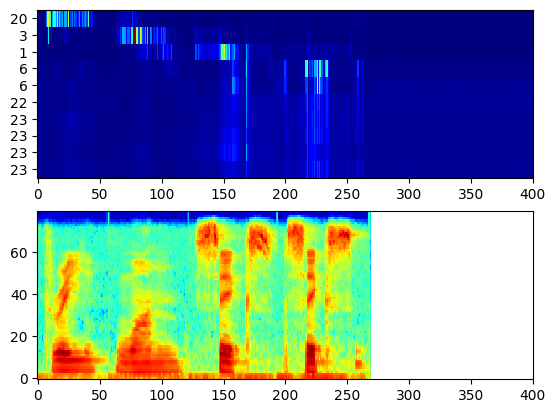

In [ ]:
ifile = 1
x, y = testset[ifile]
x = x.to(device)
y = y.to(device)
y_pred = model.generate(x[None,...])
model(x[None,:], y[None,:]) 
hyp = tokenizer.decode(y_pred)
y = y.cpu().numpy().tolist()
y0 = y
if 24 in y:
    y = y[:y.index(24)]
ref = tokenizer.decode(y)
print('ref', ref)
print('hyp', hyp)

mean_att = torch.cat(att_).mean([0, 1])

plt.clf()
plt.subplot(2,1,1)
plt.imshow(mean_att.cpu().detach().numpy(), interpolation='none', cmap='jet', aspect='auto')
ax = plt.gca()
ax.set_yticks(np.arange(len(y0)), y0)
plt.subplot(2,1,2)
plt.imshow( model.fe.fe(x).log().detach().cpu().numpy(), interpolation='none', cmap='jet', aspect='auto',origin='lower')

IPython.display.Audio(testset.files[ifile])

visualize attention

ref 9 1 7 1
hyp 9 1 7 1


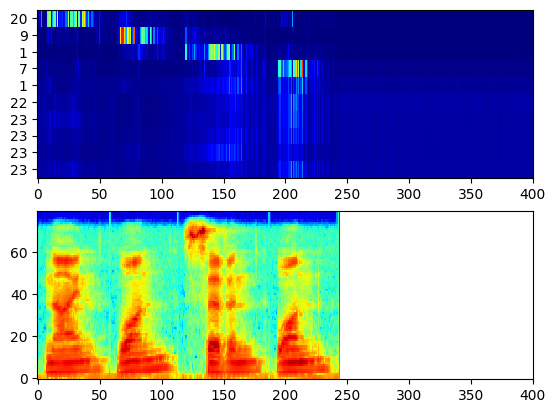

In [ ]:
ifile = 100
x, y = testset[ifile]

x = x.to(device)
y = y.to(device)
y_pred = model.generate(x[None,...])
model(x[None,:], y[None,:]) 
hyp = tokenizer.decode(y_pred)
y = y.cpu().numpy().tolist()
y0 = y
if 24 in y:
    y = y[:y.index(24)]
ref = tokenizer.decode(y)
print('ref', ref)
print('hyp', hyp)

mean_att = torch.cat(att_).mean([0, 1])

plt.clf()
plt.subplot(2,1,1)
plt.imshow(mean_att.cpu().detach().numpy(), interpolation='none', cmap='jet', aspect='auto')
ax = plt.gca()
ax.set_yticks(np.arange(len(y0)), y0)
plt.subplot(2,1,2)
plt.imshow( model.fe.fe(x).log().detach().cpu().numpy(), interpolation='none', cmap='jet', aspect='auto',origin='lower')

IPython.display.Audio(testset.files[ifile])

ref 3 7 5 7
hyp 3 7 5 7


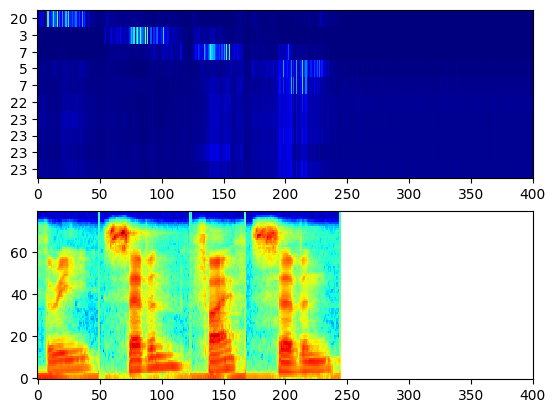

In [ ]:
ifile = 133
x, y = testset[ifile]

x = x.to(device)
y = y.to(device)
y_pred = model.generate(x[None,...])
model(x[None,:], y[None,:]) 
hyp = tokenizer.decode(y_pred)
y = y.cpu().numpy().tolist()
y0 = y
if 24 in y:
    y = y[:y.index(24)]
ref = tokenizer.decode(y)
print('ref', ref)
print('hyp', hyp)

mean_att = torch.cat(att_).mean([0, 1])

plt.clf()
plt.subplot(2,1,1)
plt.imshow(mean_att.cpu().detach().numpy(), interpolation='none', cmap='jet', aspect='auto')
ax = plt.gca()
ax.set_yticks(np.arange(len(y0)), y0)
plt.subplot(2,1,2)
plt.imshow( model.fe.fe(x).log().detach().cpu().numpy(), interpolation='none', cmap='jet', aspect='auto',origin='lower')

IPython.display.Audio(testset.files[ifile])